In [2]:
import bte
import pandas as pd
import numpy as np

In [3]:
tree = bte.MATree("/Users/reem/2026_updated_tree.pb")


Finished 'from_pb' in 156.066 seconds


In [3]:
df = pd.read_csv("/Users/reem/merged_bte_final.tsv", sep="\t")        
df.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],['G15910T'],1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020,1
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],['G4162T'],1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020,1
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,['T13090C'],1,2,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,2
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"['C1191T', 'C11674T']",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,0.0,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020,1
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],['T15821C'],1,3,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,1


In [11]:
# extract True negatives (data before 2021) that meet the MOV threshold according to our model
df_neg = df[df["date"]<2021]
len(df_neg)

399352

In [12]:
df_mov = df_neg[(df_neg["LLR"]>3) & (df_neg["sum_contexts"]>2)]
len(df_mov)

2

In [5]:
import ast
import numpy as np

df["Counts_parsed"] = df["Counts"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df["GtoA_counts_int"] = df["Counts_parsed"].apply(lambda x: x.get("G>A", 0) if isinstance(x, dict) else 0)
df["AtoG_counts_int"] = df["Counts_parsed"].apply(lambda x: x.get("A>G", 0) if isinstance(x, dict) else 0)
df["CtoT_counts_int"] = df["Counts_parsed"].apply(lambda x: x.get("C>T", 0) if isinstance(x, dict) else 0)
df["TtoC_counts_int"] = df["Counts_parsed"].apply(lambda x: x.get("T>C", 0) if isinstance(x, dict) else 0)

# Total transition counts
df["transition_counts"] = (df["GtoA_counts_int"] + df["AtoG_counts_int"] + 
                           df["CtoT_counts_int"] + df["TtoC_counts_int"])

# Proportions
df["GtoA_prop"] = df["GtoA_counts_int"] / df["num_mutations"]
df["CtoT_prop"] = df["CtoT_counts_int"] / df["num_mutations"]
df["transition_prop"] = df["transition_counts"] / df["num_mutations"]

# ============================================================
# CALCULATE Ts/Tv RATIO FOR FOCOSI METHOD
# ============================================================

# Transversions = total mutations - transitions
df["transversions"] = df["num_mutations"] - df["transition_counts"]

# Ts/Tv ratio (handle division by zero)
df["ts_tv_ratio"] = df["transition_counts"] / df["transversions"].replace(0, np.inf)

# ============================================================
# DEFINE ALL THREE DETECTION METHODS
# ============================================================

# Sanderson et al. (2023)
sanderson_mov = (
    (df["GtoA_prop"] > 0.25) &
    (df["CtoT_prop"] > 0.20) &
    (df["transition_prop"] > 0.90) &
    (df["num_mutations"] >= 10)
)

# Focosi et al. (threshold-based with Ts/Tv)
focosi_mov = (
    (df["transition_counts"] >= 13) &           # Ts >= 13
    (df["GtoA_prop"] >= 0.20) &                 # G->A >= 20%
    (df["ts_tv_ratio"] > 3)                     # Ts/Tv > 3
)

# Your model's LLR method
llr_mov = (df["LLR"] > 3) & (df["sum_contexts"] > 2)

# ============================================================
# PRE-2021 FALSE POSITIVE ANALYSIS
# ============================================================

df["date"] = pd.to_numeric(df["date"], errors="coerce")
pre_2021 = df[df["date"] < 2021]

sanderson_fp = sanderson_mov & (df["date"] < 2021)
focosi_fp = focosi_mov & (df["date"] < 2021)
llr_fp = llr_mov & (df["date"] < 2021)

print("=== FALSE POSITIVE RATES (pre-2021) ===")
print(f"Total pre-2021 nodes: {len(pre_2021)}")
print(f"\nSanderson:")
print(f"  FP count: {sanderson_fp.sum()}")
print(f"  FP rate: {sanderson_fp.sum() / len(pre_2021) * 100:.4f}%")
print(f"\nFocosi:")
print(f"  FP count: {focosi_fp.sum()}")
print(f"  FP rate: {focosi_fp.sum() / len(pre_2021) * 100:.4f}%")
print(f"\nLLR:")
print(f"  FP count: {llr_fp.sum()}")
print(f"  FP rate: {llr_fp.sum() / len(pre_2021) * 100:.4f}%")

print(f"\n=== SANDERSON FALSE POSITIVES (pre-2021) ===")
sanderson_fps_df = df[sanderson_fp][["node_id", "date", "num_mutations", "GtoA_prop", "CtoT_prop", "transition_prop", "transition_counts", "ts_tv_ratio", "LLR", "sum_contexts"]]
print(f"Count: {len(sanderson_fps_df)}")
if len(sanderson_fps_df) > 0:
    print(sanderson_fps_df.head(10))

print(f"\n=== FOCOSI FALSE POSITIVES (pre-2021) ===")
focosi_fps_df = df[focosi_fp][["node_id", "date", "num_mutations", "GtoA_prop", "transition_counts", "ts_tv_ratio", "LLR", "sum_contexts"]]
print(f"Count: {len(focosi_fps_df)}")
if len(focosi_fps_df) > 0:
    print(focosi_fps_df.head(10))

print(f"\n=== LLR FALSE POSITIVES (pre-2021) ===")
llr_fps_df = df[llr_fp][["node_id", "date", "num_mutations", "GtoA_prop", "CtoT_prop", "transition_prop", "transition_counts", "ts_tv_ratio", "LLR", "sum_contexts"]]
print(f"Count: {len(llr_fps_df)}")
if len(llr_fps_df) > 0:
    print(llr_fps_df.head(10))

# ============================================================
# OVERLAP ANALYSIS (FULL DATASET)
# ============================================================

print("\n=== OVERLAP ANALYSIS (full dataset) ===")
print(f"Sanderson total positives: {sanderson_mov.sum()}")
print(f"Focosi total positives: {focosi_mov.sum()}")
print(f"LLR total positives: {llr_mov.sum()}")

=== FALSE POSITIVE RATES (pre-2021) ===
Total pre-2021 nodes: 399352

Sanderson:
  FP count: 12
  FP rate: 0.0030%

Focosi:
  FP count: 6
  FP rate: 0.0015%

LLR:
  FP count: 2
  FP rate: 0.0005%

=== SANDERSON FALSE POSITIVES (pre-2021) ===
Count: 12
                                                   node_id  date  \
12724    India/HR-NCDC-909300/2020|EPI_ISL_2459299|2020...  2020   
211220   India/CH-ICMR-MCL_4036_5642/2020|EPI_ISL_34736...  2020   
417522   Denmark/DCGC-21722/2020|EPI_ISL_758327|2020-12-21  2020   
442839                                         node_207183  2020   
484508   hCoV-19/Ecuador/INSPI-M1A/2020|2020-11-24|2022...  2020   
516097                                         node_240680  2020   
516887   Philippines/PH-PGC-00060/2020|EPI_ISL_2154019|...  2020   
520176                                         node_242423  2020   
522384   Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...  2020   
8754928   Peru/LIM-INS-193/2020|EPI_ISL_1092344|2020-09-02  2020   


In [ ]:
# All sanderson MOV in 2022
sanderson_2022 = sanderson_mov & (df["date"] >= 2022) & (df["date"] < 2023)
print(df[sanderson_2022][["node_id", "date", "num_mutations", "spectrum", "GtoA_prop", "CtoT_prop", "transition_prop", "LLR", "sum_contexts"]])
df[sanderson_2022].to_csv("/Users/reem/sanderson_2022.tsv", sep="\t", index=False)

In [ ]:
# How many Sanderson nodes in 2022?
sanderson_2022 = df[(sanderson_mov) & (df["date"] == 2022)]
print(f"Sanderson 2022: {len(sanderson_2022)}")

In [7]:
df.groupby("date").size().reindex([2020, 2021, 2022, 2023, 2024, 2025], fill_value=0)

date
2020     392149
2021    3512086
2022    3359968
2023    1051324
2024     437747
2025     182426
dtype: int64

In [ ]:
LLR_2022 = df[(llr_mov) & (df["date"] == 2022)]
print(f"LLR 2022: {len(LLR_2022)}")

In [ ]:
# Number of nodes in 2022 that meet the MOV in both models (llr and sanderson)
both_2022 = df[(llr_mov & sanderson_mov) & (df["date"] == 2022)]
print(f"Both models 2022: {len(both_2022)}")

In [14]:
# LLR Relaxed comparison with Sanderson (sum_contexts > 1 instead of > 2)
llr_mov = (df["LLR"] > 3) & (df["sum_contexts"] > 1)
llr_years = df[
    llr_mov & 
    (df["date"] >= 2020) & (df["date"] <= 2025)
].groupby("date").size().reindex([2020, 2021, 2022, 2023, 2024, 2025], fill_value=0)

print(f"LLR total: {llr_years.sum()}")
date_filter = (df["date"] >= 2020) & (df["date"] <= 2025)

sanderson_years = df[
    sanderson_mov & 
    (df["date"] >= 2020) & (df["date"] <= 2025)
].groupby("date").size().reindex([2020, 2021, 2022, 2023, 2024, 2025], fill_value=0)

print(f"Sanderson total: {sanderson_years.sum()}")

# Then recalculate the three groups
sanderson_only_years = df[sanderson_mov & ~llr_mov & date_filter]\
    .groupby("date").size().reindex([2020, 2021, 2022, 2023, 2024, 2025], fill_value=0)

llr_only_years = df[~sanderson_mov & llr_mov & date_filter]\
    .groupby("date").size().reindex([2020, 2021, 2022, 2023, 2024, 2025], fill_value=0)

both_years = df[sanderson_mov & llr_mov & date_filter]\
    .groupby("date").size().reindex([2020, 2021, 2022, 2023, 2024, 2025], fill_value=0)

# Sanity check
print("\nYear | Sand_only | LLR_only | Both | Sand_total | LLR_total")
for y in [2020, 2021, 2022, 2023, 2024, 2025]:
    print(f"{y} | {sanderson_only_years[y]} | {llr_only_years[y]} | {both_years[y]} | {sanderson_only_years[y]+both_years[y]} | {llr_only_years[y]+both_years[y]}")

LLR total: 1277
Sanderson total: 1499

Year | Sand_only | LLR_only | Both | Sand_total | LLR_total
2020 | 11 | 9 | 1 | 12 | 10
2021 | 54 | 58 | 4 | 58 | 62
2022 | 271 | 146 | 515 | 786 | 661
2023 | 183 | 103 | 319 | 502 | 422
2024 | 45 | 21 | 70 | 115 | 91
2025 | 12 | 17 | 14 | 26 | 31


In [ ]:
# LLR Strict comparison with Sanderson (sum_contexts > 2)
years_list = [2020, 2021, 2022, 2023, 2024, 2025]
llr_mov = (df["LLR"] > 3) & (df["sum_contexts"] > 2)
llr_years = df[
    llr_mov & 
    (df["date"] >= 2020) & (df["date"] <= 2025)
].groupby("date").size().reindex(years_list, fill_value=0)

print(f"LLR total: {llr_years.sum()}")
date_filter = (df["date"] >= 2020) & (df["date"] <= 2025)

sanderson_years = df[
    sanderson_mov & 
    (df["date"] >= 2020) & (df["date"] <= 2025)
].groupby("date").size().reindex(years_list, fill_value=0)

print(f"Sanderson total: {sanderson_years.sum()}")

# Then recalculate the three groups
sanderson_only_years = df[sanderson_mov & ~llr_mov & date_filter]\
    .groupby("date").size().reindex(years_list, fill_value=0)

llr_only_years = df[~sanderson_mov & llr_mov & date_filter]\
    .groupby("date").size().reindex(years_list, fill_value=0)

both_years = df[sanderson_mov & llr_mov & date_filter]\
    .groupby("date").size().reindex(years_list, fill_value=0)

# Sanity check
print("\nYear | Sand_only | LLR_only | Both | Sand_total | LLR_total")
for y in years_list:
    print(f"{y} | {sanderson_only_years[y]} | {llr_only_years[y]} | {both_years[y]} | {sanderson_only_years[y]+both_years[y]} | {llr_only_years[y]+both_years[y]}")

LLR total: 1001
Sanderson total: 1499

Year | Sand_only | LLR_only | Both | Sand_total | LLR_total
2020 | 11 | 1 | 1 | 12 | 2
2021 | 58 | 16 | 0 | 58 | 16
2022 | 332 | 106 | 454 | 786 | 560
2023 | 236 | 63 | 266 | 502 | 329
2024 | 49 | 12 | 66 | 115 | 78
2025 | 16 | 6 | 10 | 26 | 16


In [7]:
# Adding Focosi analysis

focosi_years = df[focosi_mov & date_filter].groupby("date").size().reindex(years_list, fill_value=0)
focosi_only_years = df[focosi_mov & ~llr_mov & ~sanderson_mov & date_filter].groupby("date").size().reindex(years_list, fill_value=0)
all_three_years = df[sanderson_mov & focosi_mov & llr_mov & date_filter].groupby("date").size().reindex(years_list, fill_value=0)

print("\nYear | Sand_only | Focosi_only | LLR_only | All_three | Sand_total | Focosi_total | LLR_total")
for y in [2020, 2021, 2022, 2023, 2024, 2025]:
    print(f"{y} | {sanderson_only_years[y]} | {focosi_only_years[y]} | {llr_only_years[y]} | {all_three_years[y]} | {sanderson_only_years[y]+all_three_years[y]} | {focosi_only_years[y]+all_three_years[y]} | {llr_only_years[y]+all_three_years[y]}")


Year | Sand_only | Focosi_only | LLR_only | All_three | Sand_total | Focosi_total | LLR_total
2020 | 11 | 5 | 1 | 0 | 11 | 5 | 1
2021 | 58 | 50 | 16 | 0 | 58 | 50 | 16
2022 | 332 | 147 | 106 | 108 | 440 | 255 | 214
2023 | 236 | 102 | 63 | 87 | 323 | 189 | 150
2024 | 49 | 26 | 12 | 23 | 72 | 49 | 35
2025 | 16 | 17 | 6 | 4 | 20 | 21 | 10


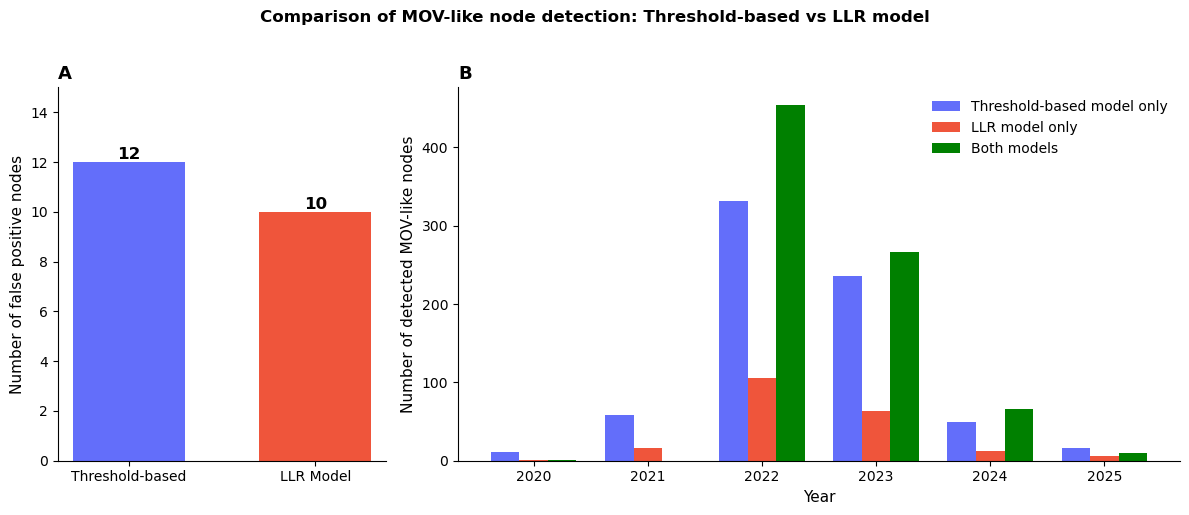

In [28]:
# PLOTTING LLR Relaxed comparison with Sanderson (sum_contexts > 1 instead of > 2)
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),gridspec_kw={'width_ratios': [1, 2.2]}) 

# === PANEL A: False positive comparison ===
methods = ["Threshold-based", "LLR Model"]
fp_counts = [12, 10]
colors = ["#636EFA", "#EF553B"]

bars = ax1.bar(methods, fp_counts, color=colors, width=0.6, linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, fp_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             str(val), ha="center", va="bottom", fontsize=12, fontweight="bold")

ax1.set_ylabel("Number of false positive nodes", fontsize=11)
ax1.set_title("A", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylim(0, 15)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# === PANEL B: Year distribution per method ===
# I want to add a bar for each year where both sanderson and llr_mov agree (overlap bar)
x = np.arange(len([2020, 2021, 2022, 2023, 2024, 2025]))
width = 0.25

bars1 = ax2.bar(x - width, sanderson_only_years, width, label="Threshold-based model only",
                color=colors[0], linewidth=0.8)
bars2 = ax2.bar(x , llr_only_years, width, label="LLR model only",
                color=colors[1], linewidth=0.8)
bars3 = ax2.bar(x + width, both_years, width, label="Both models",
                color="green", linewidth=0.8)

ax2.set_xlabel("Year", fontsize=11)
ax2.set_ylabel("Number of detected MOV-like nodes", fontsize=11)
ax2.set_title("B", fontsize=13, fontweight="bold", loc="left")
ax2.set_xticks(x)
ax2.set_xticklabels([2020, 2021, 2022, 2023, 2024, 2025])
ax2.legend(frameon=False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Comparison of MOV-like node detection: Threshold-based vs LLR model",
             fontsize=12, y=1.02, fontweight="bold")

plt.tight_layout()
#plt.savefig("/Users/reem/molnupiravir_paper/Figures/model_comparison_relaxed.pdf", bbox_inches="tight")
plt.show()

In [21]:
llr_strict = (df["LLR"] > 3) & (df["sum_contexts"] > 2)
llr_strict_years = df[
    llr_strict & 
    (df["date"] >= 2020) & (df["date"] <= 2025)
].groupby("date").size().reindex([2020, 2021, 2022, 2023, 2024, 2025], fill_value=0)

print(llr_strict_years)

date
2020      2
2021     16
2022    560
2023    329
2024     78
2025     16
dtype: int64


In [21]:
# SAME PLOT but strict LLR MOV definition (LLR > 3 and sum_contexts > 2)
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.12, column_widths=[0.45, 0.55])

years_list = [2020, 2021, 2022, 2023, 2024, 2025]
x = np.arange(len(years_list))
width = 0.25

# Panel A - false positives (unchanged)
methods = ["Threshold\nbased", "Ts/Tv\nfiltering", "LLR\ncontext"]
fp_counts = [12, 6, 2]
colors_fp = ["#636EFA", "#EF553B", "#2ca02c"]

fig.add_trace(
    go.Bar(
        x=methods, 
        y=fp_counts, 
        name="FP count", 
        marker=dict(color=colors_fp, line=dict(color='black', width=0.5)),
        showlegend=False,
        text=[f"{count}" for count in fp_counts],
        textposition="outside",
        textfont=dict(size=18)
    ), 
    row=1, col=1
)


# Add traces for panel B
fig.add_trace(go.Bar(x=years_list, y=sanderson_only_years, name="Sanderson only", marker_color='#1f77b4', showlegend=True), row=1, col=2)
fig.add_trace(go.Bar(x=years_list, y=llr_only_years, name="LLR only", marker_color="#ff520e", showlegend=True), row=1, col=2)
fig.add_trace(go.Bar(x=years_list, y=all_three_years, name="All three", marker_color="#2ca02c", showlegend=True), row=1, col=2)

width_in = 3.3
height_in = 2
dpi = 300


fig.update_layout(
    width=int(width_in * dpi),    
    height=int(height_in * dpi),
    margin=dict(l=60, r=20, t=50, b=100),
    template='simple_white',
    barmode='group',  
    legend=dict(
        font=dict(size=18),
        x=0.98,
        y=0.98,
        xanchor='right',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='black',
        borderwidth=0.5
    )
)

# Panel A axes
fig.update_xaxes(
    title_text="Method",
    tickmode='linear',
    title_font=dict(size=18, color='black'),
    tickfont=dict(size=14, color='black'),
    linecolor='black',
    linewidth=1,
    row=1, col=1
)

fig.update_yaxes(
    title_text="False positive count (pre-2021)",
    title_font=dict(size=18, color='black'),
    tickfont=dict(size=14, color='black'),
    linecolor='black',
    linewidth=1,
    tickangle=0,
    row=1, col=1
)

# Panel B axes
fig.update_xaxes(
    title_text="Year",
    tickmode='linear',
    title_font=dict(size=18, color='black'),
    tickfont=dict(size=14, color='black'),
    linecolor='black',
    linewidth=1,
    row=1, col=2
)

fig.update_yaxes(
    title_text="Number of detected molnupiravir nodes",
    title_font=dict(size=18, color='black'),
    tickfont=dict(size=14, color='black'),
    linecolor='black',
    linewidth=1,
    row=1, col=2
)

fig.add_annotation(
    text="<b>A</b>",
    xref="paper", yref="paper",
    x=-0.05, y=1.08,          
    showarrow=False,
    font=dict(size=18, color='black'),
    xanchor='left', yanchor='top'
)

fig.add_annotation(
    text="<b>B</b>",
    xref="paper", yref="paper",
    x=0.40, y=1.08,           
    showarrow=False,
    font=dict(size=18, color='black'),
    xanchor='left', yanchor='top'
)

fig.show()

fig.write_image("/Users/reem/molnupiravir_paper/Figures/model_comparison_strict.pdf")


In [30]:
from scipy.spatial.distance import cosine

results = []

for _, row in sanderson_only.iterrows():
    contexts = extract_contexts(row["mutations"], reference_genome)
    ctx_counter = Counter(contexts)
    
    for cls, ref_probs in [("G>A", GtoA_probs), ("C>T", CtoT_probs), 
                            ("T>C", TtoC_probs), ("A>G", AtoG_probs)]:
        contexts_ordered = ref_probs["Mutational_Context"].values
        mov_probs = ref_probs["Molnupiravir"].values
        normal_probs = ref_probs["Normal"].values
        
        total = sum(ctx_counter.get(c, 0) for c in contexts_ordered)
        if total == 0:
            continue
            
        seq_props = np.array([ctx_counter.get(c, 0) / total 
                              for c in contexts_ordered])
        
        sim_mov = 1 - cosine(seq_props, mov_probs)
        sim_normal = 1 - cosine(seq_props, normal_probs)
        
        results.append({
            "node_id": row["node_id"],
            "class": cls,
            "sim_mov": sim_mov,
            "sim_normal": sim_normal,
            "closer_to": "MOV" if sim_mov > sim_normal else "Normal"
        })

results_df = pd.DataFrame(results)
print(results_df.groupby(["class", "closer_to"]).size())

class  closer_to
A>G    MOV          322
       Normal       221
C>T    MOV          416
       Normal       283
G>A    MOV          418
       Normal       281
T>C    MOV          333
       Normal       223
dtype: int64


In [45]:
non_mov = df[(df["LLR"] <= 3) & (df["sum_contexts"] < 2)]
non_mov_singletons = (non_mov["num_descendants"] < 2).sum()
non_mov_total = len(non_mov)
print(f"Non-MOV singleton rate: {non_mov_singletons/non_mov_total*100:.1f}%")
print(f"MOV singleton rate: 85.1%")

Non-MOV singleton rate: 55.3%
MOV singleton rate: 85.1%


In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

# Contingency table
# [singletons, non-singletons]
mov_counts = [852, 149]  # 1001 - 852 = 149
non_mov_counts = [
    int(len(non_mov) * 0.553),  # singletons
    int(len(non_mov) * 0.447)   # non-singletons
]

table = [mov_counts, non_mov_counts]
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-square: {chi2:.2f}, p = {p:.4e}")

Chi-square: 358.73, p = 5.3207e-80
